# Understand size and distribution of contrail-sensitive regions

## 1. Download gridded CoCiP output from contrails.org
- Contrails.org provide global gridded CoCiP outputs via their API (https://apidocs.contrails.org/notebooks/research_api.html)
- Intro to gridded CoCiP: https://py.contrails.org/notebooks/CoCiPGrid.html
- Original publication: https://gmd.copernicus.org/articles/18/253/2025/
- Hourly coverage not complete - around two days are missing despite repeated API requests

## 2. Analyse ISSR distribution

- Take the gridded CoCiP output for every hour
- We take an Airbus A320 as representative aircraft with an engine efficiency of 0.32 and download the grid for the whole globe
- Identify connected regions where the energy forcing in J/m in a given hour is above a given threshold
- This threshold comes from https://gmd.copernicus.org/articles/18/253/2025/
- The grid-based CoCiP defines regions with strongly warming contrails based on the 80th percentile (5×108 J m−1) and the 95th percentile (1.5×109 J m−1) of EFcontrail per flight distance flown, both of which were derived from a 2019 global contrail simulation using the trajectory-based CoCiP (Teoh et al., 2024a).
- We therefore use 5e8 J/m as threshold
- These regions need to lie within the bounding box lon = (-90.0, 40.0) and lat = (30.0, 80.0)
- If they intersect with the bounding box - discard them (this potentially disqualifies regions that stretch into the arctic)
- Compute key stats for every identified region such as mean latitude, longitude, altitude, width, forcing etc. 
- Save all stats to giant list containing the identified regions for all hours 

### Weaknesses of this analysis
- The intersection condition implies that we potentially miss out on very big ISSRs that consistently go to the North pole or have very high longitudinal elongation
- We do not track the evolution of ISSRs over time - in consecutive hours, we consider the same ISSR but don't actually track which ISSRs are the same  - so this is really an analysis about annual average properties of ISSRs rather than a study of how individual ISSRs evolve

## 1. Download gridded CoCiP from contrails.org

In [ ]:
from datetime import datetime, timedelta
from tqdm import tqdm
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
import requests
import requests  # don’t forget to import
from google.colab import userdata
import requests

API_KEY = userdata.get('CONTRAILS_API_KEY')
URL = "https://api.contrails.org"
HEADERS = {"x-api-key": API_KEY}

START_DATE = "2024-01-09"
END_DATE   = "2024-12-31"  # inclusive
OUTDIR = "/content/drive/MyDrive/GriddedCoCip/contrails.org"

os.makedirs(OUTDIR, exist_ok=True)

start_dt = datetime.fromisoformat(START_DATE)
end_dt   = datetime.fromisoformat(END_DATE)

def download_file(dt):
    time_str = dt.strftime("%Y-%m-%dT%H")
    fname = dt.strftime("%Y%m%dT%H") + ".nc"
    outpath = os.path.join(OUTDIR, fname)

    if os.path.exists(outpath):
        return f"Skipped {time_str} (already exists)"

    params = {
        "time": time_str,
        "bbox": "-180,-89,180,89",  # global
        "engine_efficiency": 0.32,
        "aircraft_type": "A320"
    }

    try:
        r = requests.get(f"{URL}/v0/grid/cocip", params=params,
                         headers=HEADERS, timeout=120)
        if r.status_code == 200 and "netcdf" in r.headers.get("content-type", "").lower():
            with open(outpath, "wb") as f:
                f.write(r.content)
            return f"Downloaded {time_str}"
        else:
            return f"Failed {time_str}: {r.status_code} {r.reason}"
    except Exception as e:
        return f"Error {time_str}: {e}"

# Build list of datetimes
all_dts = []
curr_dt = start_dt
while curr_dt <= end_dt:
    for h in range(24):
        all_dts.append(curr_dt + timedelta(hours=h))
    curr_dt += timedelta(days=1)

# Run in parallel (tune workers to avoid server overload)
with ThreadPoolExecutor(max_workers=5) as executor:
    futures = [executor.submit(download_file, dt) for dt in all_dts]
    for future in as_completed(futures):
        print(future.result())

## File availability

In [6]:
import os
import re
import pandas as pd
from datetime import datetime

# --- CONFIG ---
FOLDER_PATH = r"G:\.shortcut-targets-by-id\10bix0f5QiOF3GSGl4hyO16V5buUcN1uP\GriddedCoCip\contrails.org"
OUTPUT_CSV = "output/issr/1_daily_nc_availability.csv"

# --- MAIN SCRIPT ---
pattern = re.compile(r"(\d{8})T(\d{2}).nc$")

# Dictionary to store available hours per day
availability = {}

for filename in os.listdir(FOLDER_PATH):
    if filename.endswith(".nc"):
        match = pattern.search(filename)
        if not match:
            continue

        date_str, hour  = match.groups()
        date = datetime.strptime(date_str, "%Y%m%d").date()

        # Record availability for that hour
        availability.setdefault(date, set()).add(int(hour))

# Build a list of rows for the CSV
rows = []
for date, hours in sorted(availability.items()):
    total_hours_available = len(hours)
    share = total_hours_available / 24  # Share of day covered
    rows.append({
        "date": date,
        "filename_pattern": f"{date.strftime('%Y%m%d')}-*-*-contrail.nc",
        "availability_share": round(share, 3)
    })

# Convert to DataFrame and save
df = pd.DataFrame(rows)
df.to_csv(OUTPUT_CSV, index=False)

print(f"✅ Wrote {OUTPUT_CSV} with {len(df)} days of data.")


✅ Wrote output/issr/1_daily_nc_availability.csv with 366 days of data.


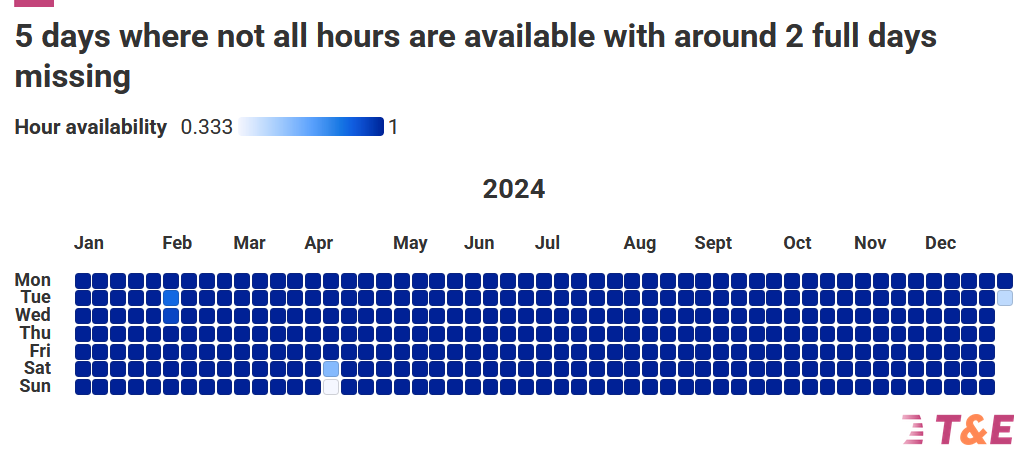

## 2. Visualise ISSRs at two different times
- This shows their scale and how fast they move

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm
import xarray as xr

def plot_map(ds, var="seg_length_km", vmin=None, vmax=None, savepath=None):
    """
    Plot a 2D map of the given variable from an xarray Dataset.
    Assumes dimensions: (flight_level, latitude, longitude).
    Sums over flight levels before plotting.
    """

    # --- Select single flight level (or sum if you want) ---
    data_2d = ds[var].sel(flight_level=360).squeeze()

    lon = ds.longitude.values
    lat = ds.latitude.values

    proj = ccrs.PlateCarree()

    # --- Define discrete color map ---
    # Boundaries define the edges of color intervals
    boundaries = [-1e15, -1e5, 1e5, 5e8, 1e15]
    # Colors for each interval
    colors = ['#75a1f4', 'white', '#ff8754', '#c2447a']
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(boundaries, cmap.N, clip=True)

    # --- Setup map ---

    proj = ccrs.AlbersEqualArea(
        central_longitude=0,  # Center of map horizontally
        central_latitude=30,  # Center vertically
        standard_parallels=(20, 40)  # Choose parallels around your region of interest
    )

    # --- Setup map ---
    fig, ax = plt.subplots(
        subplot_kw={"projection": proj},
        figsize=(7.94*2, 5.75*2)
    )

    # Pick the right viewing window
    ax.set_extent([-70., 45.0, 25., 60.], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
    ax.add_feature(cfeature.LAND, facecolor="white")
    ax.add_feature(cfeature.OCEAN, facecolor="white")

    # --- Plot data ---
    im = ax.imshow(
        data_2d.T,
        origin="lower",
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        extent=[lon.min(), lon.max(), lat.min(), lat.max()],
    )

    plt.axis('off')
    # --- Save to PNG ---
    if savepath:
        plt.savefig(savepath, bbox_inches="tight", pad_inches=0)

    plt.show()

import pandas as pd 

# These definitions follow the bounding boxes in Teoh et al.'s paper (except for Eurocontrol)
regions = {
    "Global": {"lon_min": -180, "lon_max": 180, "lat_min": -90, "lat_max": 90},
    "USA": {"lon_min": -126, "lon_max": -66, "lat_min": 23, "lat_max": 50},
    "Europe": {"lon_min": -12, "lon_max": 20, "lat_min": 35, "lat_max": 60},
    "Eurocontrol": {"lon_min": -30.0, "lon_max": 45.0, "lat_min": 25.0, "lat_max": 72.0},
    "Eurocontrol + North Atlantic": {"lon_min": -70.0, "lon_max": 45.0, "lat_min": 25.0, "lat_max": 72.0},
    "East_Asia": {"lon_min": 103, "lon_max": 150, "lat_min": 15, "lat_max": 48},
    "Southeast_Asia": {"lon_min": 87.5, "lon_max": 130, "lat_min": -10, "lat_max": 20},
    "Latin_America": {"lon_min": -85, "lon_max": -35, "lat_min": -60, "lat_max": 15},
    "Africa_Middle_East": {"lon_min": -20, "lon_max": 50, "lat_min": -35, "lat_max": 40},
    "China": {"lon_min": 73.5, "lon_max": 135, "lat_min": 18, "lat_max": 53.5},
    "India": {"lon_min": 68, "lon_max": 97.5, "lat_min": 8, "lat_max": 35.5},
    "North Atlantic": {"lon_min": -70, "lon_max": -5, "lat_min": 40, "lat_max": 63},
    "North Pacific": {"lon_min": 140, "lon_max": -120, "lat_min": 35, "lat_max": 65},
    "Arctic": {"lon_min": -180, "lon_max": 180, "lat_min": 66.5, "lat_max": 90}, 
}

def subset_region(ds, region):
    """Return subset of dataset within the region bounding box."""
    lon_min, lon_max = region["lon_min"], region["lon_max"]
    lat_min, lat_max = region["lat_min"], region["lat_max"]

    # Handle longitude wrap-around (e.g. North Pacific)
    if lon_min < lon_max:
        subset = ds.sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max))
    else:
        # For regions crossing the dateline (e.g. 140E–120W)
        subset1 = ds.sel(longitude=slice(lon_min, 180))
        subset2 = ds.sel(longitude=slice(-180, lon_max))
        subset = xr.concat([subset1, subset2], dim="longitude")
        subset = subset.sel(latitude=slice(lat_min, lat_max))
    
    return subset

C:\Users\TE\AppData\Local\Temp\ipykernel_105440\1185826183.py:2: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(r"data\issr\20240101T00.nc")


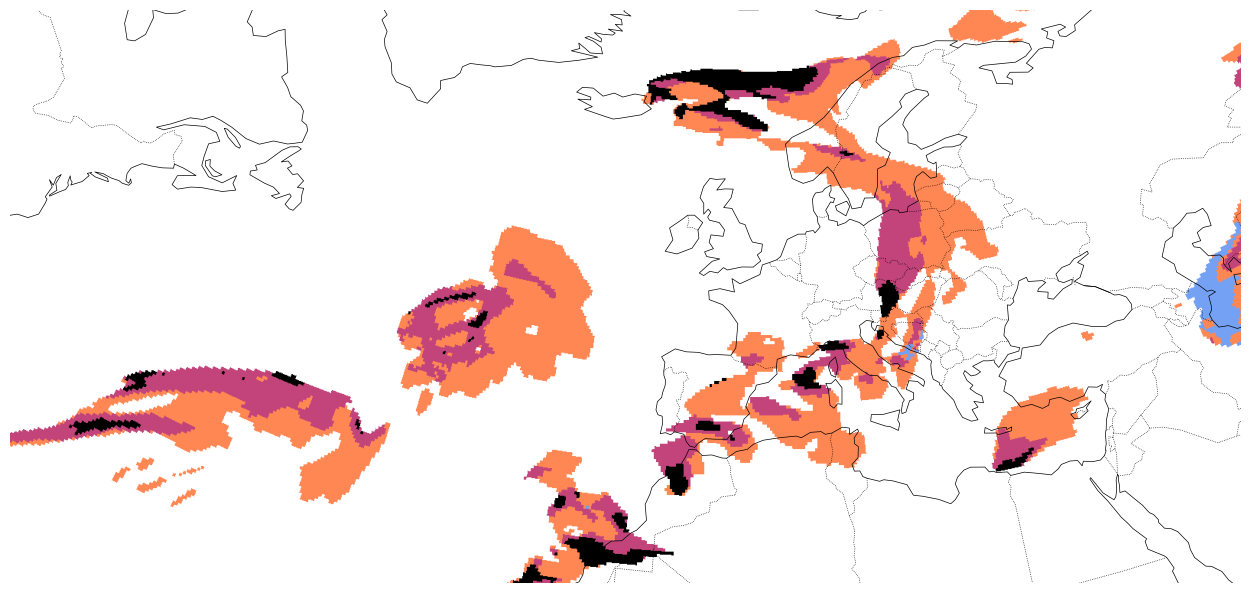

In [ ]:
import xarray as xr 
ds = xr.open_dataset(r"data\issr\20240101T00.nc")
plot_map(ds, var="ef_per_m", vmin=0, vmax=1e9, savepath="output/forcing/2_issr_map.png")

![image-2.png](figures\3_issr\issr_2_contrail_map@2x.png)

C:\Users\TE\AppData\Local\Temp\ipykernel_105440\1247820388.py:10: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  datasets = [subset_region(xr.open_dataset(r"data\issr\20240101T00.nc"), regions["Eurocontrol + North Atlantic"]),
C:\Users\TE\AppData\Local\Temp\ipykernel_105440\1247820388.py:11: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rel

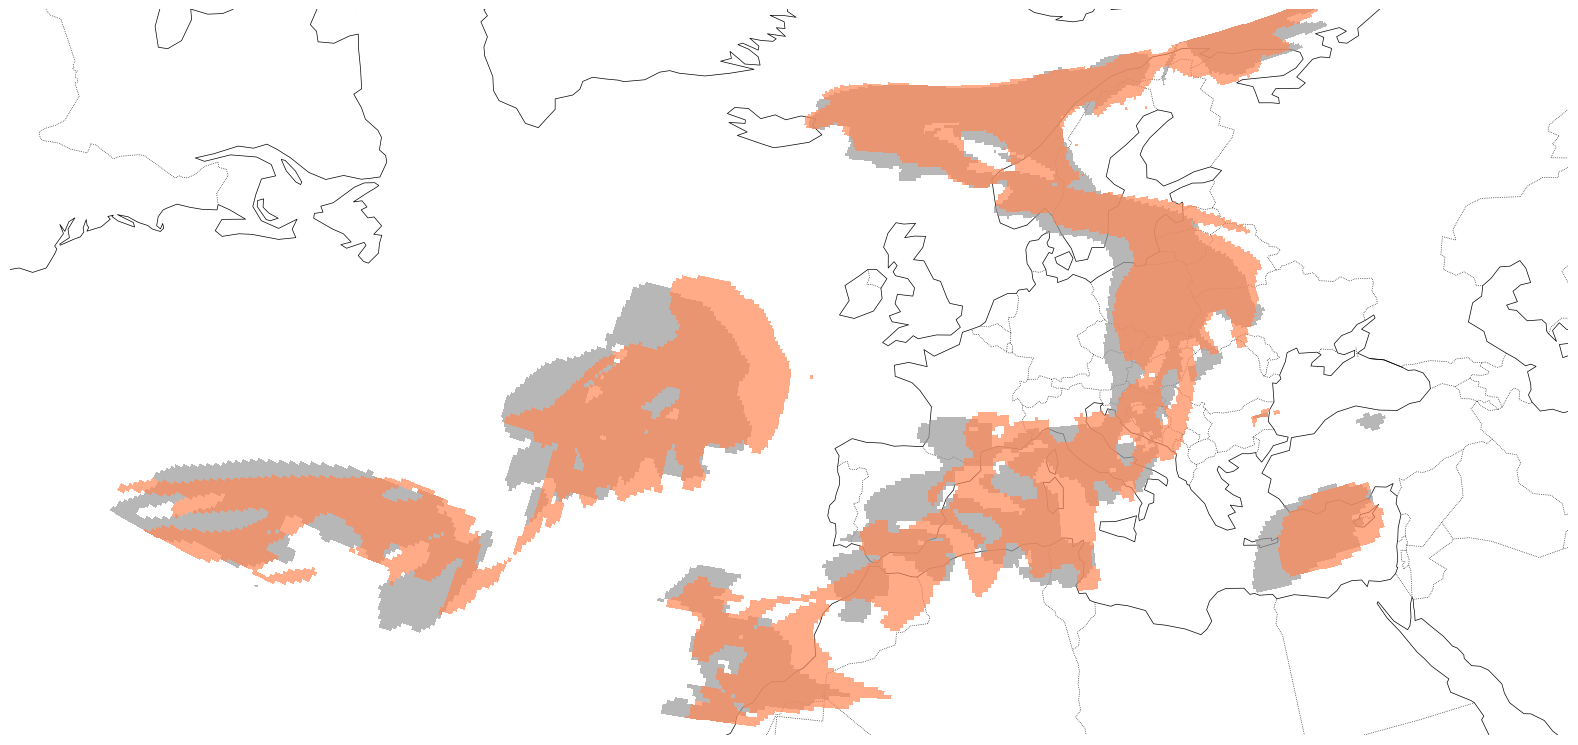

In [16]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from scipy.ndimage import gaussian_filter

# Load two snapshots 3 hours apart
datasets = [subset_region(xr.open_dataset(r"data\issr\20240101T00.nc"), regions["Eurocontrol + North Atlantic"]),
            subset_region(xr.open_dataset(r"data\issr\20240101T03.nc"), regions["Eurocontrol + North Atlantic"])]


# --- Setup base map ---
ds0 = datasets[0]
lon = ds0.longitude.values
lat = ds0.latitude.values

proj = ccrs.AlbersEqualArea(
    central_longitude=0,  # Center of map horizontally
    central_latitude=30,  # Center vertically
    standard_parallels=(20, 40)  # Choose parallels around your region of interest
)

# --- Setup map ---
fig, ax = plt.subplots(
    subplot_kw={"projection": proj},
    figsize=(7.94*2, 5.75*2)
)

# Pick the right viewing window
ax.set_extent([-70., 45.0, 25., 60.], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
ax.add_feature(cfeature.LAND, facecolor="white")
ax.add_feature(cfeature.OCEAN, facecolor="white")

import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# --- Discrete colormap: 0=white, 1=orange, 2=magenta ---
cmap = ListedColormap(['white', '#999999', '#4d45ff'])
bounds = [-0.5, 0.5, 1.5, 2.5]
norm = BoundaryNorm(bounds, cmap.N)

ds0, ds1 = datasets[0], datasets[1]
lon = ds0.longitude.values
lat = ds0.latitude.values
extent = [lon.min(), lon.max(), lat.min(), lat.max()]

# --- Binary masks at FL360 ---
m0 = (ds0["ef_per_m"].sel(flight_level=360).squeeze().values > 0)
m1 = (ds1["ef_per_m"].sel(flight_level=360).squeeze().values)

# --- Make categorical layers with transparent background ---
# NaNs are treated as "bad" and will be fully transparent
layer0 = np.where(m0, 1.0, np.nan)  # regions at T0 shown as color for value 1
layer1 = np.where(m1, m1,  np.nan) # regions at T+12h shown as color for value 2

# Make NaNs transparent
cmap_with_alpha = cmap.copy()
cmap_with_alpha.set_bad((0, 0, 0, 0))

# --- Draw the two transparent overlays ---
# transpose + origin='lower' so x~lon, y~lat consistent with your imshow
ax.imshow(
    layer0.T, origin="lower", interpolation="nearest",
    cmap=cmap_with_alpha, norm=norm, transform=ccrs.PlateCarree(), extent=extent, alpha=0.7, zorder=3
)


# --- Define discrete color map ---
# Boundaries define the edges of color intervals
boundaries = [-1e15, 1e15]
# Colors for each interval
colors = ['#ff8754']
cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries, cmap.N, clip=True)

ax.imshow(
    layer1.T, origin="lower", interpolation="nearest",
    cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), extent=extent, alpha=0.7, zorder=4
)

plt.axis("off")
plt.tight_layout()
plt.savefig("output/forcing/3_issr_movement.png", bbox_inches="tight", pad_inches=0)

plt.show()

#

![image-2.png](figures\3_issr\issr_3_movement@2x.png)

## 3. Analyse ISSR distribution


In [ ]:
import numpy as np
import pandas as pd
import shapely
import xarray as xr
import regionmask
from scipy import ndimage
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import glob
import os

# ---------------------------------------
# CONFIGURATION
# ---------------------------------------
input_pattern = "2024*.nc"
output_file = "contrail_region_details_2024.csv"
n_workers = os.cpu_count() - 2  # use all but two cores

# European airspace bounding box - this is a very generous bounding box that also includes parts of North America
bbox = shapely.geometry.box(-70.0, 20.0, 70.0, 90.0)
mask_reg = regionmask.Regions([bbox])

R = 6371.0  # Earth radius in km
big_hit_region_threshold = 5 * 1e8 # J/m

# ---------------------------------------
# HELPER FUNCTION
# ---------------------------------------
def process_file(filepath):
    """Process one hourly CoCiP file and return region-level metrics."""
    try:
        ds = xr.open_dataset(filepath)
        ds_hr = ds.isel(time=0)
        ef = ds_hr["ef_per_m"].transpose("latitude", "longitude", "flight_level")
        lat = ef.latitude.values
        lon = ef.longitude.values
        lev = ef.flight_level.values
        time = pd.to_datetime(str(ds.time.values[0]))

        # European airspace mask
        mask2d = mask_reg.mask(lon, lat)
        ecac_mask_2d = np.isfinite(mask2d.values)
        ecac_mask_3d = np.repeat(ecac_mask_2d[:, :, None], ef.shape[2], axis=2)

        # Area grid

        # Ensure that lat-long grid is regular
        assert(np.diff(lat).min() == np.diff(lat).max())
        assert(np.diff(lon).min() == np.diff(lon).max())

        # Get grid spacing in radians
        dlat = np.deg2rad(np.abs(np.diff(lat)).mean())
        dlon = np.deg2rad(np.abs(np.diff(lon)).mean())
        lat_rad = np.deg2rad(lat)

        # Approximate latitude dependent area of a single cell
        cell_area_lat = (R**2) * dlat * dlon * np.cos(lat_rad)

        # Create 3D array that contain grid cell array
        area_2d = np.repeat(cell_area_lat[:, None], len(lon), axis=1)
        area_3d = np.repeat(area_2d[:, :, None], ef.shape[2], axis=2)

        # Flight level heights (m)
        # Approximate that 1 feet = 0.3048 (even though this is barometric altitude)
        fl_ft = lev * 100.0
        fl_m = fl_ft * 0.3048
        lev_heights_m = fl_m

        # Positive forcing inside 
        pos_mask_3d = (ef.values > big_hit_region_threshold) & ecac_mask_3d
        pos_mask_3d = np.where(np.isnan(ef.values), False, pos_mask_3d)
                
        structure = ndimage.generate_binary_structure(rank=3, connectivity=1)
        
        # Standard labeling
        # labeled_3d is a 3D array where regions below the threshold are 0 and all connected regions
        # get the same numerical label, n_label is the number of labels = number of ISSRs
        labeled_3d, n_labels = ndimage.label(pos_mask_3d, structure=structure)
        if n_labels == 0:
            return pd.DataFrame([])

        # Discard regions that touch the boundary
        valid_mask = ecac_mask_3d.astype(bool)

        # boundary mask: edges
        boundary = np.zeros_like(valid_mask, dtype=bool)
        boundary[0, :, :]  = True
        boundary[-1, :, :] = True
        boundary[:, 0, :]  = True
        boundary[:, -1, :] = True
        boundary[:, :, 0]  = True
        boundary[:, :, -1] = True

        # Add internal holes (adjacent to invalids) to boundary mask
        eroded = ndimage.binary_erosion(valid_mask, structure=structure, border_value=0)
        boundary |= valid_mask & ~eroded

        # Get a list of labels that touch the boundary to discard them
        boundary_labels = np.unique(labeled_3d[boundary])
        boundary_labels = boundary_labels[boundary_labels > 0]

        print("Number of labels that touch the boundary: ", len(boundary_labels))

        # Keep only interior labels
        all_labels = np.unique(labeled_3d)
        all_labels = all_labels[all_labels > 0]
        print("Number of labels: ", len(all_labels))
        interior_labels = np.setdiff1d(all_labels, boundary_labels)

        # Restrict the labeling to interior regions
        mask_interior = np.isin(labeled_3d, interior_labels)
        print("Number of interior labels: ", len(interior_labels))
        labeled_3d[~mask_interior] = 0
        n_labels = len(interior_labels)
            
        indices = np.unique(labeled_3d)
        ef_vals = np.where(pos_mask_3d, ef.values, np.nan)

        # Prepare coordinate grids
        LAT2D, LON2D = np.meshgrid(lat, lon, indexing="ij")
        LAT3D = np.repeat(LAT2D[:, :, None], ef.shape[2], axis=2)
        LON3D = np.repeat(LON2D[:, :, None], ef.shape[2], axis=2)

        # Compute per-region stats
        region_records = []
        for lab in indices:
            mask = (labeled_3d == lab)
            if not np.any(mask) or lab == 0:
                continue

            weights = area_3d[mask]
            lat_pts = LAT3D[mask]
            lon_pts = LON3D[mask]

            # horizontal extent
            min_lat = np.nanmin(lat_pts)
            max_lat = np.nanmax(lat_pts)
            min_lon = np.nanmin(lon_pts)
            max_lon = np.nanmax(lon_pts)

            # vertical extent ---
            levels_present = np.any(np.any(mask, axis=0), axis=0)
            lev_ids = np.where(levels_present)[0]
            if len(lev_ids) == 0:
                continue

            # Lat/Lon centroid (area-weighted)
            weights = area_3d[mask]
            lat_mean = np.average(LAT3D[mask], weights=weights)
            
            # Circular mean of longitude (in radians)
            # The key concern here is to ensure that this is invariant
            # under the choice of longitudinal coordinate system
            lon_rad = np.deg2rad(lon_pts)
            lon_mean_rad = np.arctan2(
                np.average(np.sin(lon_rad), weights=weights),
                np.average(np.cos(lon_rad), weights=weights)
            )
            lon_mean = np.degrees(lon_mean_rad)
            
            
            # Lateral extent
            # Area grid and grid spacing
            dlat = np.abs(np.diff(lat)).mean()          # degrees
            dlon = np.abs(np.diff(lon)).mean()          # degrees
            
            # Forcing
            ef_std  = np.nanstd (ef_vals[mask])
            ef_mean = np.nanmean(ef_vals[mask])
            ef_max  = np.nanmax (ef_vals[mask])

            # Flight level (mean) and thickness
            levels_present = np.any(np.any(mask, axis=0), axis=0)
            lev_ids = np.where(levels_present)[0]
            if len(lev_ids) == 0:
                continue
            
            dz = np.mean(np.diff(lev_heights_m)) if len(lev_heights_m) > 1 else 0
            zmin = lev_heights_m[lev_ids].min()
            zmax = lev_heights_m[lev_ids].max()
            min_fl = lev[lev_ids].min()
            max_fl = lev[lev_ids].max()

            # Area per flight level 
            area_by_fl = {}
            for i in lev_ids:
                mask_fl = mask[:, :, i]
                area_by_fl[int(lev[i])] = float(np.nansum(area_2d[mask_fl]))


            # Compute thickness of flight level
            thickness_m   = zmax - zmin + dz
            thickness_std = np.std(lev_heights_m[lev_ids])
            mean_FL = np.mean(lev[lev_ids])

            
            # Area (km²)
            area_km2 = np.nansum(area_3d[mask])
            # Volume (km^3)
            volume_km3 = area_km2 * thickness_m / 1000

            # Save region record
            region_records.append({
                "time":          time,
                "file":          os.path.basename(filepath),
                "region_id":     lab,
                "area_km2":      area_km2,
                "pt in mask":    mask.sum(),
                "vol_km3":       volume_km3,
                "thickness_m":   thickness_m,
                "std_thickness": thickness_std,
                "mean_FL":       mean_FL,
                "mean_lat":      lat_mean,
                "mean_lon":      lon_mean,
                "mean_forcing":  ef_mean,
                "max_forcing":   ef_max,
                "std_forcing":   ef_std,
                "min_lat": min_lat,
                "max_lat": max_lat,
                "min_lon": min_lon,
                "max_lon": max_lon,
                "min_FL":  min_fl,
                "max_FL":  max_fl,
                "area_by_FL": area_by_fl,
            })

        ds.close()
        return pd.DataFrame(region_records), labeled_3d, n_labels

    except Exception as e:
        print(f"⚠️ Error processing {filepath}: {e}")
        return pd.DataFrame([])

### Helper to run region detection

In [ ]:
  
import traceback

# ---------------------------------------
# MAIN EXECUTION BLOCK 
# This execution block has some features for restarting a run if it fails
# It also performs regular saves
# Running this with 30 cores takes around 24h
# ---------------------------------------
def main():
    files = sorted(glob.glob(input_pattern))
    print(f"Found {len(files)} hourly files.")
    if not files:
        print("⚠️ No files matched the pattern.")
        return

    # --- optional: resume capability ---
    if os.path.exists(output_file):
        existing = pd.read_csv(output_file)
        done_files = set(existing["file"].unique())
        files = [f for f in files if os.path.basename(f) not in done_files]
        all_dfs = [existing]
        print(f"Resuming from previous run: {len(done_files)} already processed.")
    else:
        all_dfs = []
        done_files = set()

    n_total = len(files)
    if n_total == 0:
        print("✅ All files already processed.")
        return

    # --- partial save configuration ---
    save_every = 20  # save every N files
    temp_file = output_file.replace(".csv", "_partial.csv")

    try:
        with ProcessPoolExecutor(max_workers=n_workers) as executor:
            futures = {executor.submit(process_file, f): f for f in files}
            processed = 0

            for fut in tqdm(as_completed(futures), total=n_total, desc="Processing files"):
                filepath = futures[fut]
                try:
                    df_part, _, _ = fut.result()
                    if not df_part.empty:
                        all_dfs.append(df_part)
                        done_files.add(os.path.basename(filepath))
                except Exception as e:
                    print(f"⚠️ Failure in {filepath}: {e}")
                    traceback.print_exc(limit=1)
                    continue

                processed += 1
                # --- periodic save ---
                if processed % save_every == 0:
                    try:
                        df_temp = pd.concat(all_dfs, ignore_index=True)
                        df_temp.to_csv(temp_file, index=False)
                        print(f"💾 Saved interim results ({processed}/{n_total}) to {temp_file}")
                    except Exception as e:
                        print(f"⚠️ Could not save interim CSV: {e}")

    except KeyboardInterrupt:
        print("\n⛔ Interrupted by user. Saving current progress...")
    except Exception as e:
        print(f"❌ Unexpected error in main loop: {e}")
    finally:
        # --- final save ---
        if all_dfs:
            df_final = pd.concat(all_dfs, ignore_index=True)
            df_final.to_csv(output_file, index=False)
            print(f"✅ Saved {len(df_final)} total region records to {output_file}")
        else:
            print("⚠️ No valid data processed (nothing to save).")



# ---------------------------------------
# ENTRY POINT (required for multiprocessing)
# ---------------------------------------
if __name__ == "__main__":
    main()

### 3  b. Test algorithm for one hour

In [27]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

filepath = "data/issr/20240101T00.nc"
ds = xr.open_dataset(filepath)
df, labeled_3d, n_labels = process_file(filepath)


C:\Users\TE\AppData\Local\Temp\ipykernel_105440\2520059127.py:6: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(filepath)
C:\Users\TE\AppData\Local\Temp\ipykernel_105440\4280786859.py:32: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default wa

Number of labels that touch the boundary:  447
Number of labels:  1603
Number of interior labels:  1156


In [29]:
df["area_by_FL"]

0                               {280: 140.82603454589844}
1                                   {280: 589.8056640625}
2                                 {320: 147.451416015625}
3                                  {300: 16233.009765625}
4                                {280: 973.8967895507812}
                              ...                        
1151                             {330: 323.5274963378906}
1152                            {340: 1830.2762451171875}
1153                                 {370: 2427.96484375}
1154                             {290: 868.4537353515625}
1155    {340: 697.1288452148438, 350: 10094.6591796875...
Name: area_by_FL, Length: 1156, dtype: object

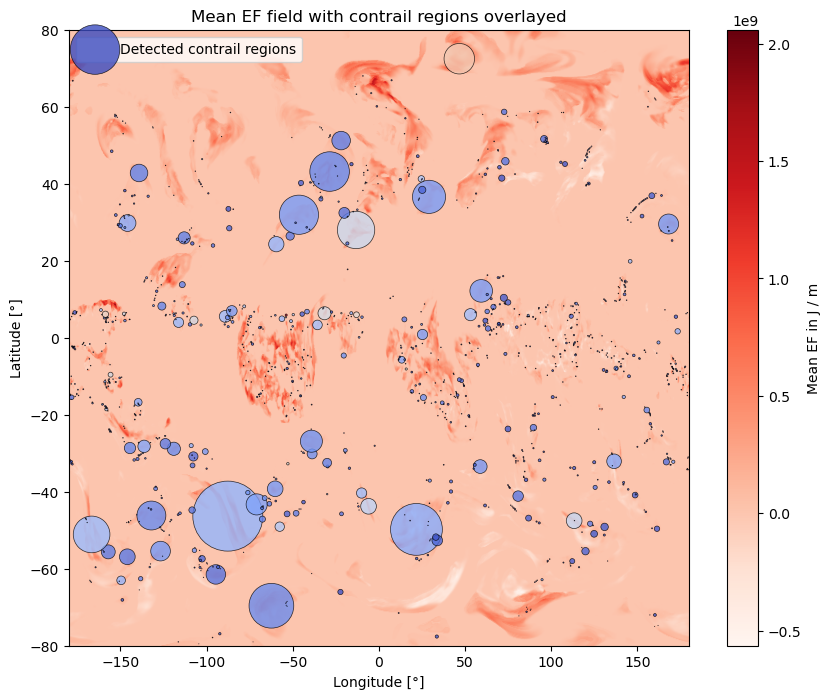

In [99]:

# Assuming ef_per_m has dims (time, latitude, longitude, flight_level)
ef = ds["ef_per_m"]

# --- average over flight levels (and time if present)
ef_mean = ef.mean(dim=[d for d in ef.dims if d in ["flight_level", "time"]])

fig, ax = plt.subplots(figsize=(10, 8))
lon_min, lon_max = ds.longitude.min(), ds.longitude.max()
lat_min, lat_max = ds.latitude.min(), ds.latitude.max()

# --- background: mean forcing field
pcm = ax.imshow(
    ef_mean.T, origin="lower", cmap="Reds",
    extent=[lon_min, lon_max, lat_min, lat_max],
    aspect="auto"
)

cbar = plt.colorbar(pcm, ax=ax, label="Mean EF in J / m")

# --- overlay: region centroids
sc = ax.scatter(
    df["mean_lon"], df["mean_lat"],
    s=df["area_km2"] / 3e3,   # bubble size scaled to area
    c=df["mean_forcing"], cmap="coolwarm", edgecolor="k", linewidth=0.5,
    alpha=0.8, label="Detected contrail regions"
)

ax.set_xlabel("Longitude [°]")
ax.set_ylabel("Latitude [°]")
ax.set_title("Mean EF field with contrail regions overlayed")
ax.legend()
plt.show()



## 4. Analyse contrail-sensitive region thickness

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Load and prepare data ---
file_path = "data/issr/contrail_region_details_2024.csv"
df = pd.read_csv(file_path, parse_dates=["time"])

# Optional: filter out non-physical or missing values
df = df[df["thickness_m"] > 0].copy()

# Convert thickness from meters to feet
df["thickness_ft"] = df["thickness_m"] * 3.28084  # 1 m = 3.28084 ft

# --- Sort and compute cumulative volume ---
df_sorted = df.sort_values("thickness_ft").reset_index(drop=True)

# Compute cumulative volume (km³)
df_sorted["cum_vol_km3"] = df_sorted["vol_km3"].cumsum()

# Normalize to percent of total (optional)
df_sorted["cum_vol_pct"] = df_sorted["cum_vol_km3"] / df_sorted["vol_km3"].sum() * 100

# --- Compute cumulative fraction (CDF) for sample count ---
thickness_sorted = df_sorted["thickness_ft"].values
fraction = np.arange(1, len(thickness_sorted) + 1) / len(thickness_sorted) * 100  # percent
df_sorted["cum_frac_pct"] = fraction

# --- Simplify while retaining step shape ---
mask = np.r_[True, np.abs(np.diff(thickness_sorted)) > 1e-4]  # detect where it changes
change_indices = np.where(mask)[0]

# Keep the point before each change (if possible)
keep_indices = np.unique(np.r_[change_indices, change_indices - 1])
keep_indices = keep_indices[(keep_indices >= 0) & (keep_indices < len(fraction))]

# Simplified dataframe
df_steps = df_sorted.iloc[keep_indices].reset_index(drop=True)



# --- Select and rename relevant columns ---
df_export = df_steps[["cum_frac_pct", "cum_vol_pct", "thickness_ft"]].rename(columns={
    "cum_frac_pct": "Cumulative Fraction (%)",
    "cum_vol_pct": "Cumulative Volume (%)",
    "thickness_ft": "ISSR Thickness (ft)"
})

# --- Export and preview ---
output_path = "output/issr/4_issr_depth_distribution.csv"
df_export.to_csv(output_path, index=False)


![image.png](figures\3_issr\issr_4_depth_volume@2x.png)

## 5. Output contrail region sample

In [ ]:
file_path = "data/issr/contrail_region_details_2024.csv"
df = pd.read_csv(file_path, parse_dates=["time"]).sample(2_000)
df.to_csv("output/issr/5_contrail_region_sample.csv")

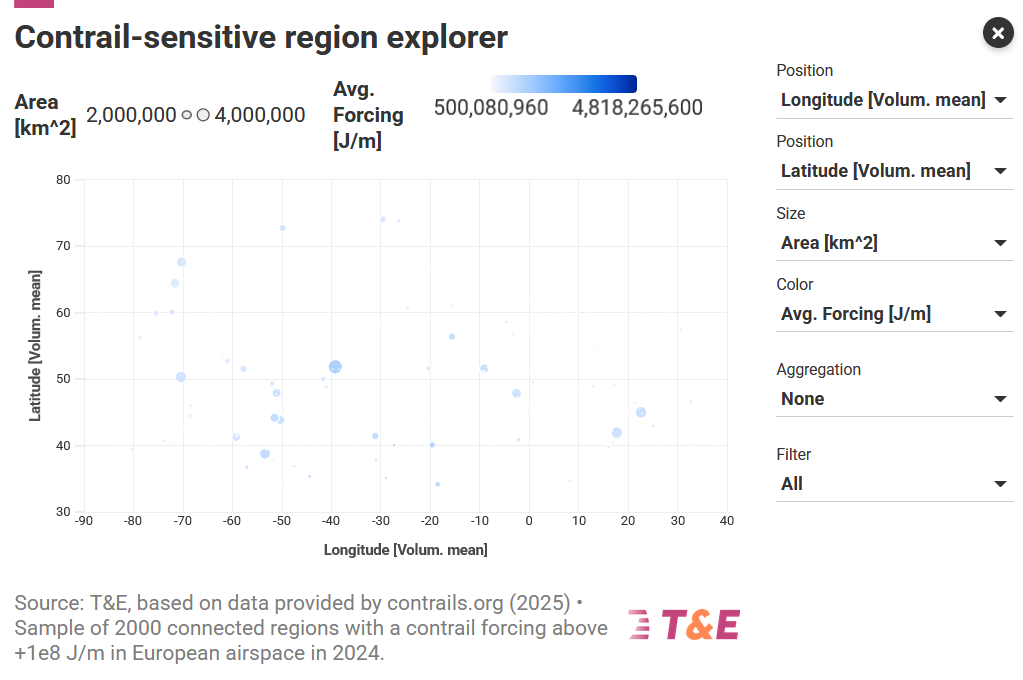

## 6. How large are typical vertical deviations?

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import ast  # for safely parsing area_by_FL dicts

# --- Load and prepare data ---
file_path = "data/issr/contrail_region_details_2024_partial.csv"
df = pd.read_csv(file_path, parse_dates=["time"])

# --- Parse area_by_FL strings into dicts ---
def parse_area_dict(s):
    if pd.isna(s):
        return {}
    try:
        return ast.literal_eval(s)
    except Exception:
        return {}

df["area_by_FL"] = df["area_by_FL"].apply(parse_area_dict)

# --- Range of FLs to analyse ---
fl_range = np.arange(250, 441, 10)

# --- Compute FL bounds ---
df["fl_lower"] = df["min_FL"]
df["fl_upper"] = df["max_FL"]

# --- Function to compute encounter probability ---
def compute_issr_encounter_probability(df, fl_range):
    results = []

    for fl in fl_range:
        # Select ISSRs intersecting this FL
        df_fl = df[(df["fl_lower"] <= fl) & (df["fl_upper"] >= fl)].copy()
        if df_fl.empty:
            continue

        # --- Determine weighting based on area_by_FL ---
        def fl_weight(row):
            return row["area_by_FL"][fl]
        
        df_fl["weight"] = df_fl.apply(fl_weight, axis=1)

        # --- Vertical extent relative to FL ---
        df_fl["above_FL"] = df_fl["fl_upper"] - fl
        df_fl["below_FL"] = fl - df_fl["fl_lower"]
        df_fl["max_ext"]  = df_fl[["above_FL", "below_FL"]].max(axis=1)

        # --- Classify manoeuvre type ---
        def classify(row):
            a, b = row["above_FL"], row["below_FL"]

            # 1 move (±2 FL ≈ 2000 ft)
            if (a < 20) and (b < 20):
                return "1 move (±2 FL up & down)"
            elif (a < 20):
                return "1 move (2 FL up)"
            elif (b < 20):
                return "1 move (2 FL down)"

            # 2 moves (±4 FL ≈ 4000 ft)
            elif (a < 40) and (b < 40):
                return "2 moves (±4 FL up & down)"
            elif (a < 40):
                return "2 moves (4 FL up)"
            elif (b < 40):
                return "2 moves (4 FL down)"

            # 3+ moves (≥6 FL ≈ 6000 ft or more)
            else:
                return "≥3 moves (≥6 FL total)"


        df_fl["category"] = df_fl.apply(classify, axis=1)

        # --- Weighted percentage of ISSRs per category ---
        weighted = (
            df_fl.groupby("category")["weight"]
            .sum()
            .div(df_fl["weight"].sum())
            .mul(100)
        )
        weighted.name = fl
        results.append(weighted)

    summary = pd.DataFrame(results).fillna(0)
    summary.index.name = "Flight Level"
    return summary

# --- Compute ---
summary = compute_issr_encounter_probability(df, fl_range)

summary.to_csv("output/issr/6_typical_deviation.csv")

![image.png](figures\3_issr\issr_6_deviation_likelihood@2x.png)